# Section 7.1 Experiment 2

- `alpha_n` variation experiment
- saves raw/summary CSV outputs and the original metric/runtime figures
- also renders the 19 timing-breakdown plots and the runtime-composition figure from the same notebook

In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "reference_1_section7_1":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import default_exp2_config, default_output_dir, run_and_save_experiment2
from src.common import compute_global_metric_limits, render_all_section7_visualizations

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


In [2]:
cfg = default_exp2_config()
show_progress = True
plot_basics = True
detailed_timing = True
outdir = default_output_dir("exp2")

cfg

Exp2Config(alpha_values=[0.05, 0.1, 0.15, 0.2], n=1152, K=3, K_prime=3, lam=0.5, q=2, r=10, p=0.7, reps=20, seed=2026)

In [3]:
outputs = run_and_save_experiment2(
    cfg=cfg,
    outdir=outdir,
    show_progress=show_progress,
    detailed_timing=detailed_timing,
    plot_basics=plot_basics,
)

outputs.to_frame()

\ [##################################]  240/ 240 (100.0%) | alpha_n=0.200 rep=20/20 method=Non-random        | elapsed=01:27 eta=00:00


,exp_key,label,outdir,raw_csv,summary_csv,timing_raw_csv,timing_summary_csv,metrics_png,runtime_png,raw_rows,summary_rows
0,exp2,Exp2 (alpha_n variation),/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,/Users/eomjeonghyeon/Documents/github_project/...,240,12


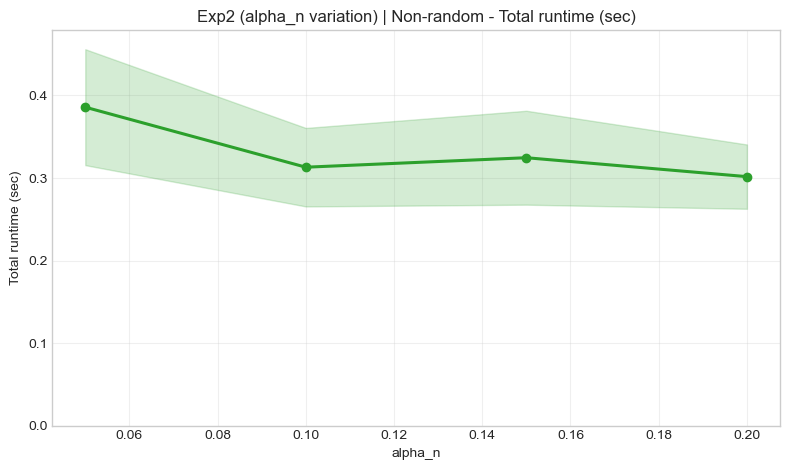

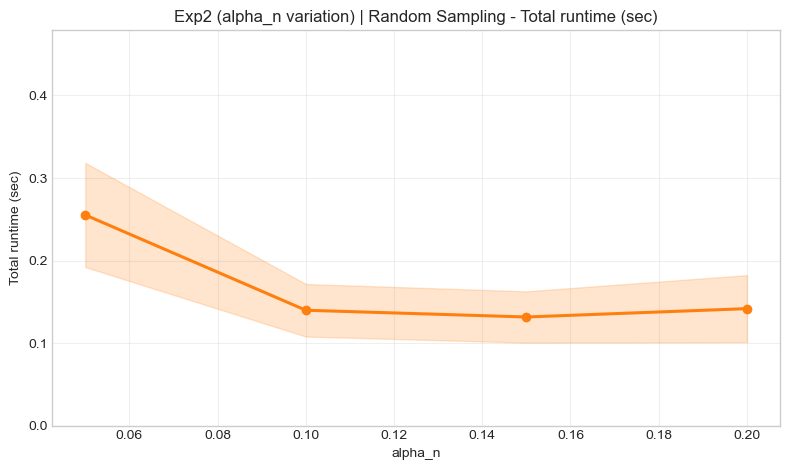

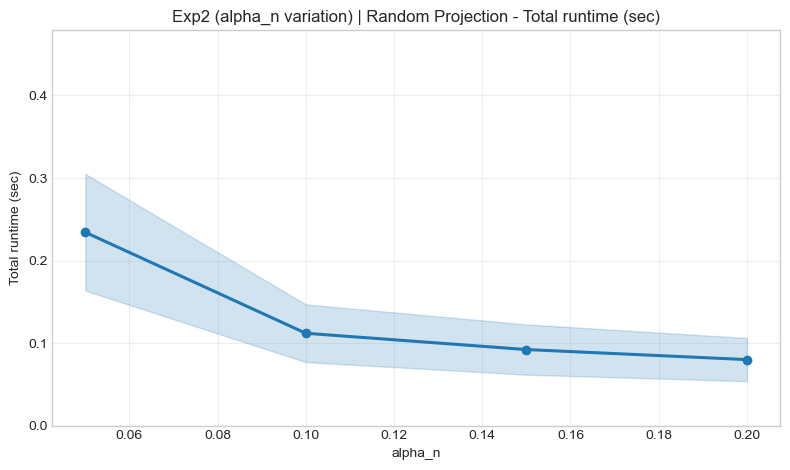

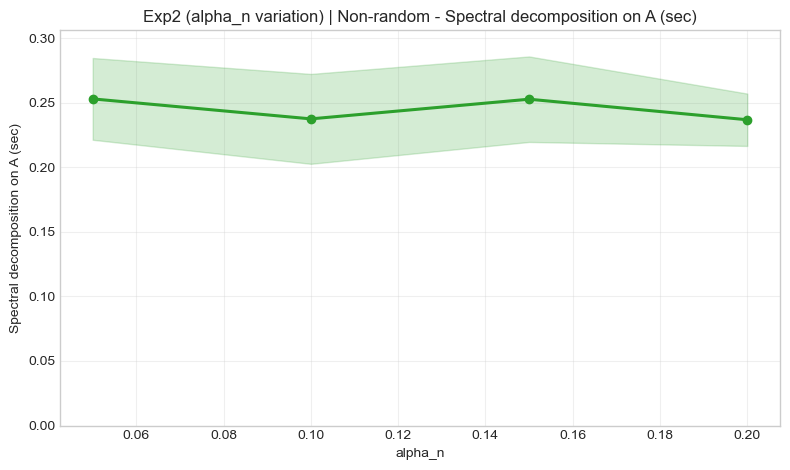

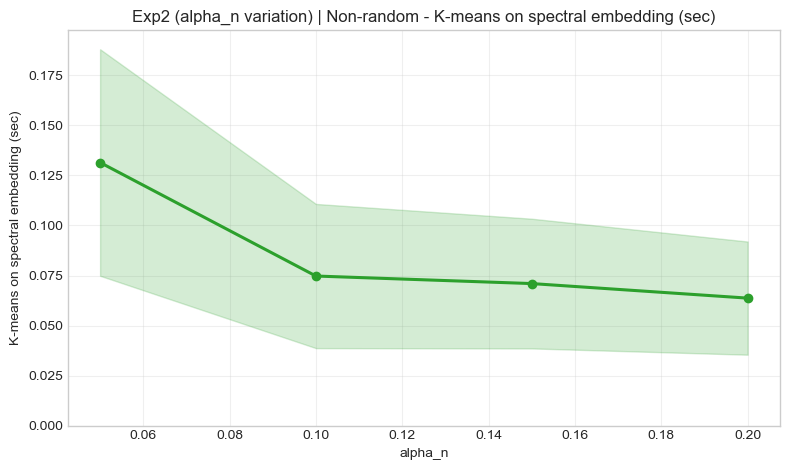

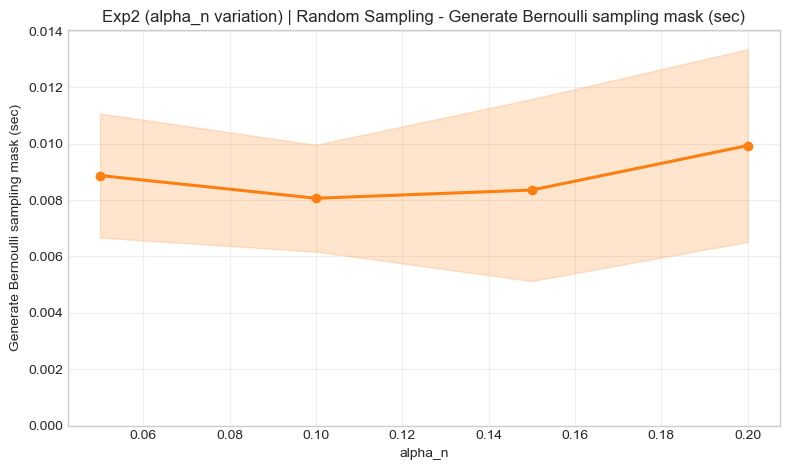

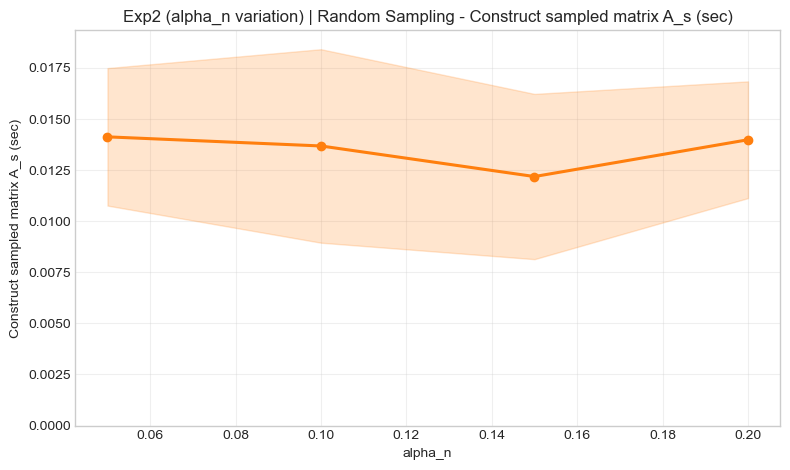

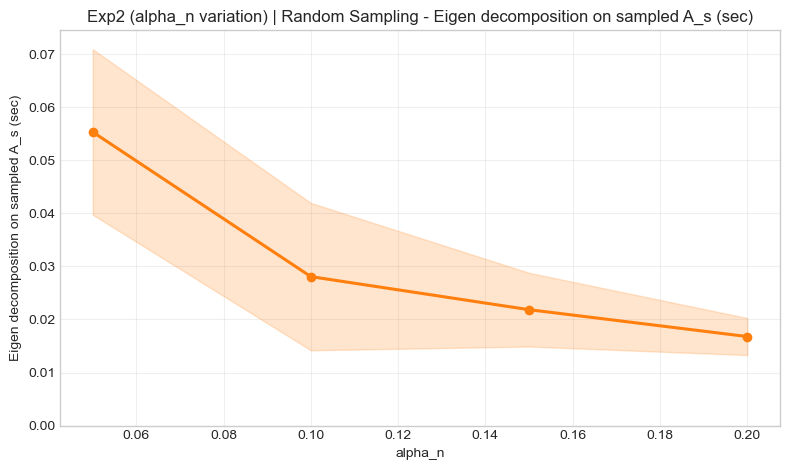

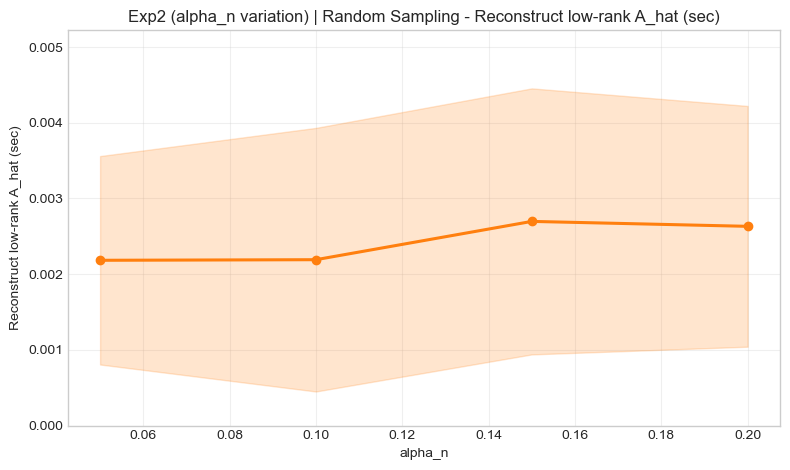

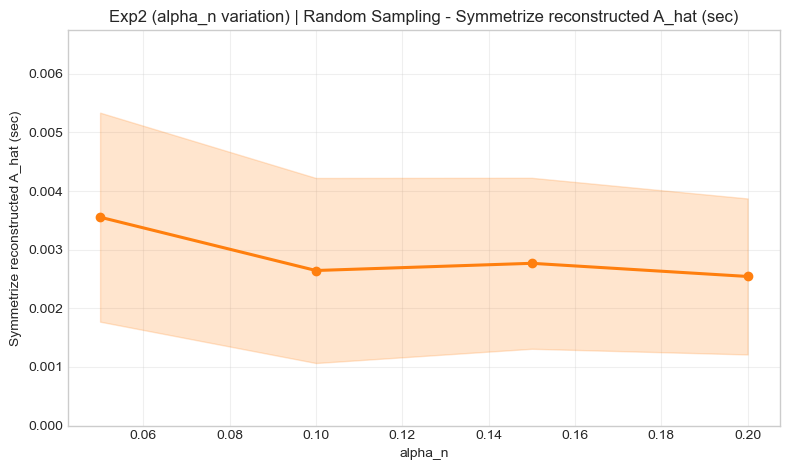

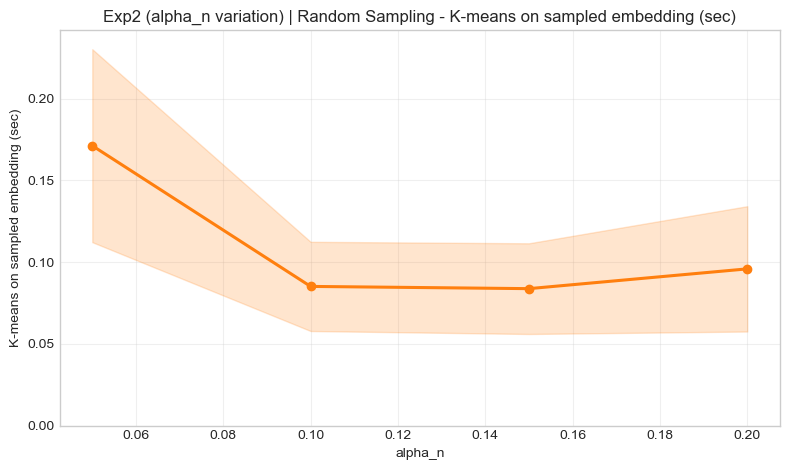

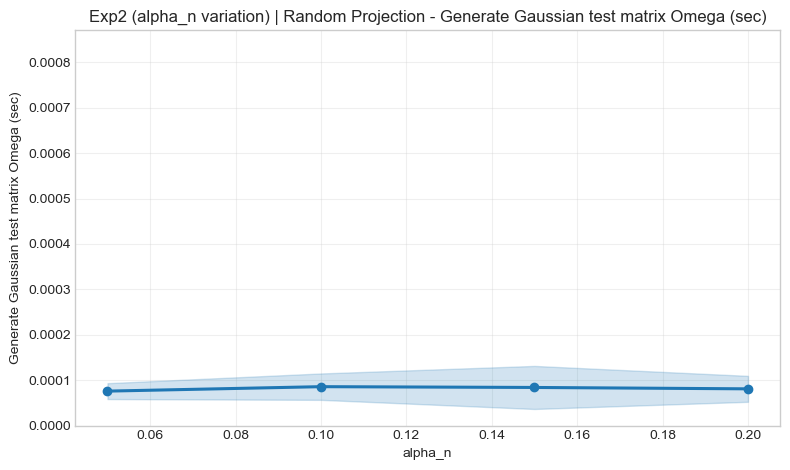

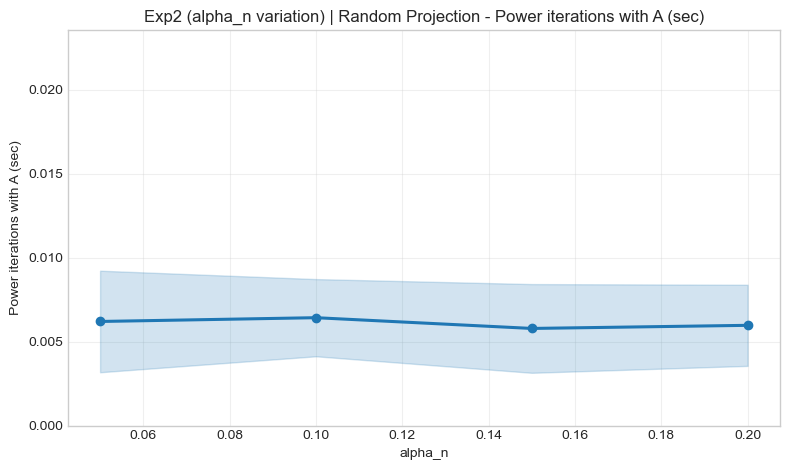

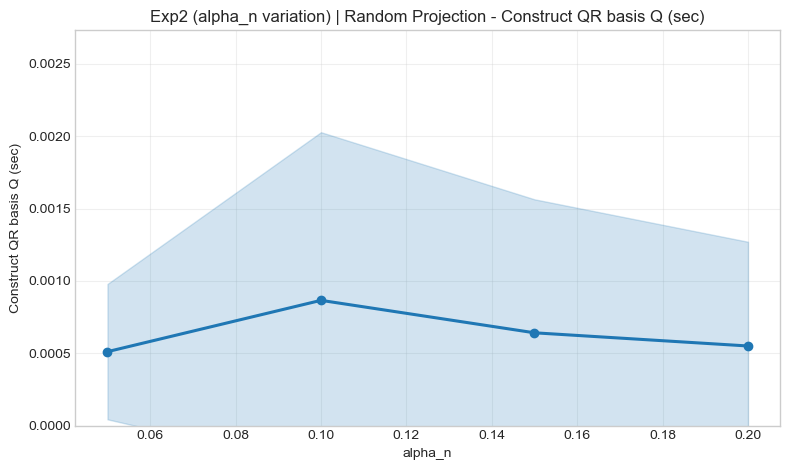

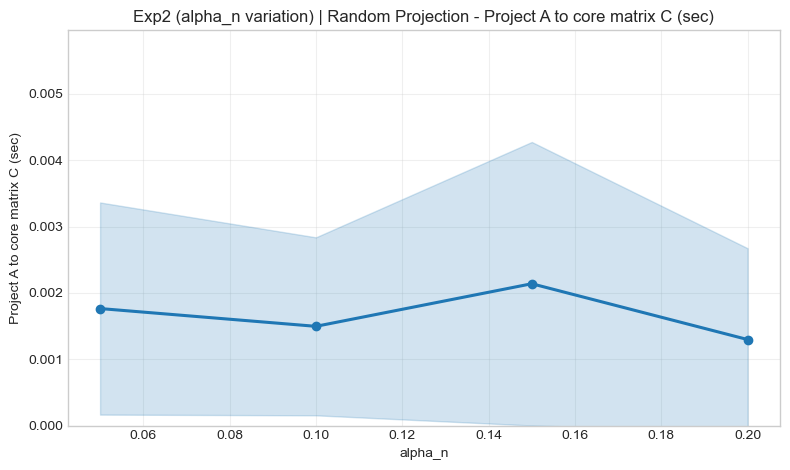

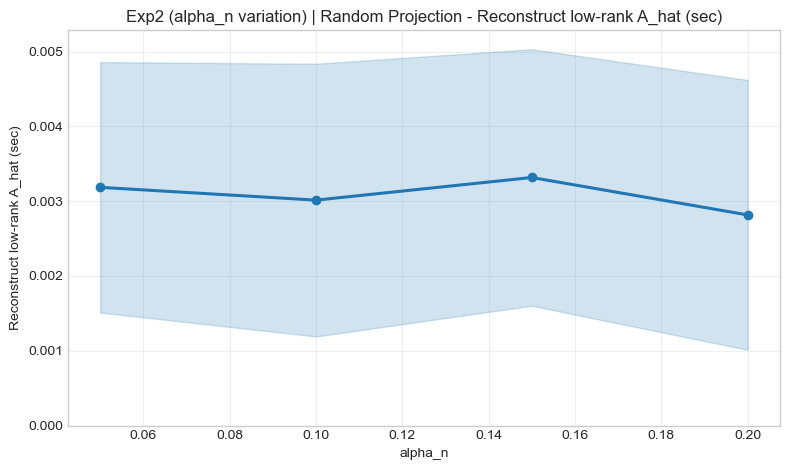

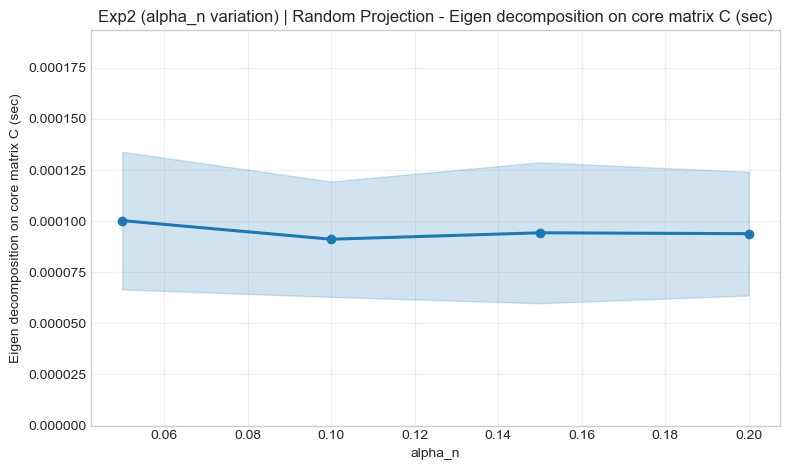

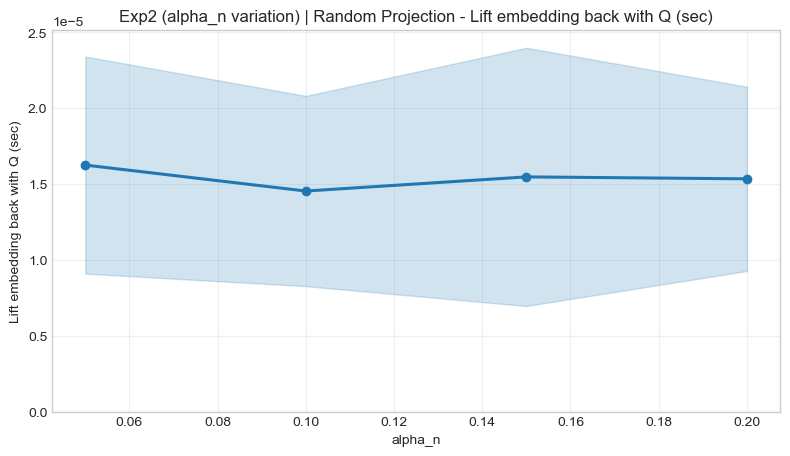

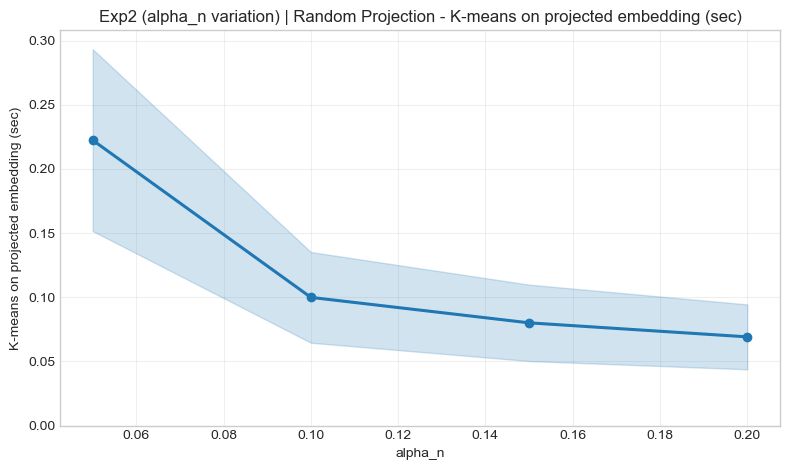

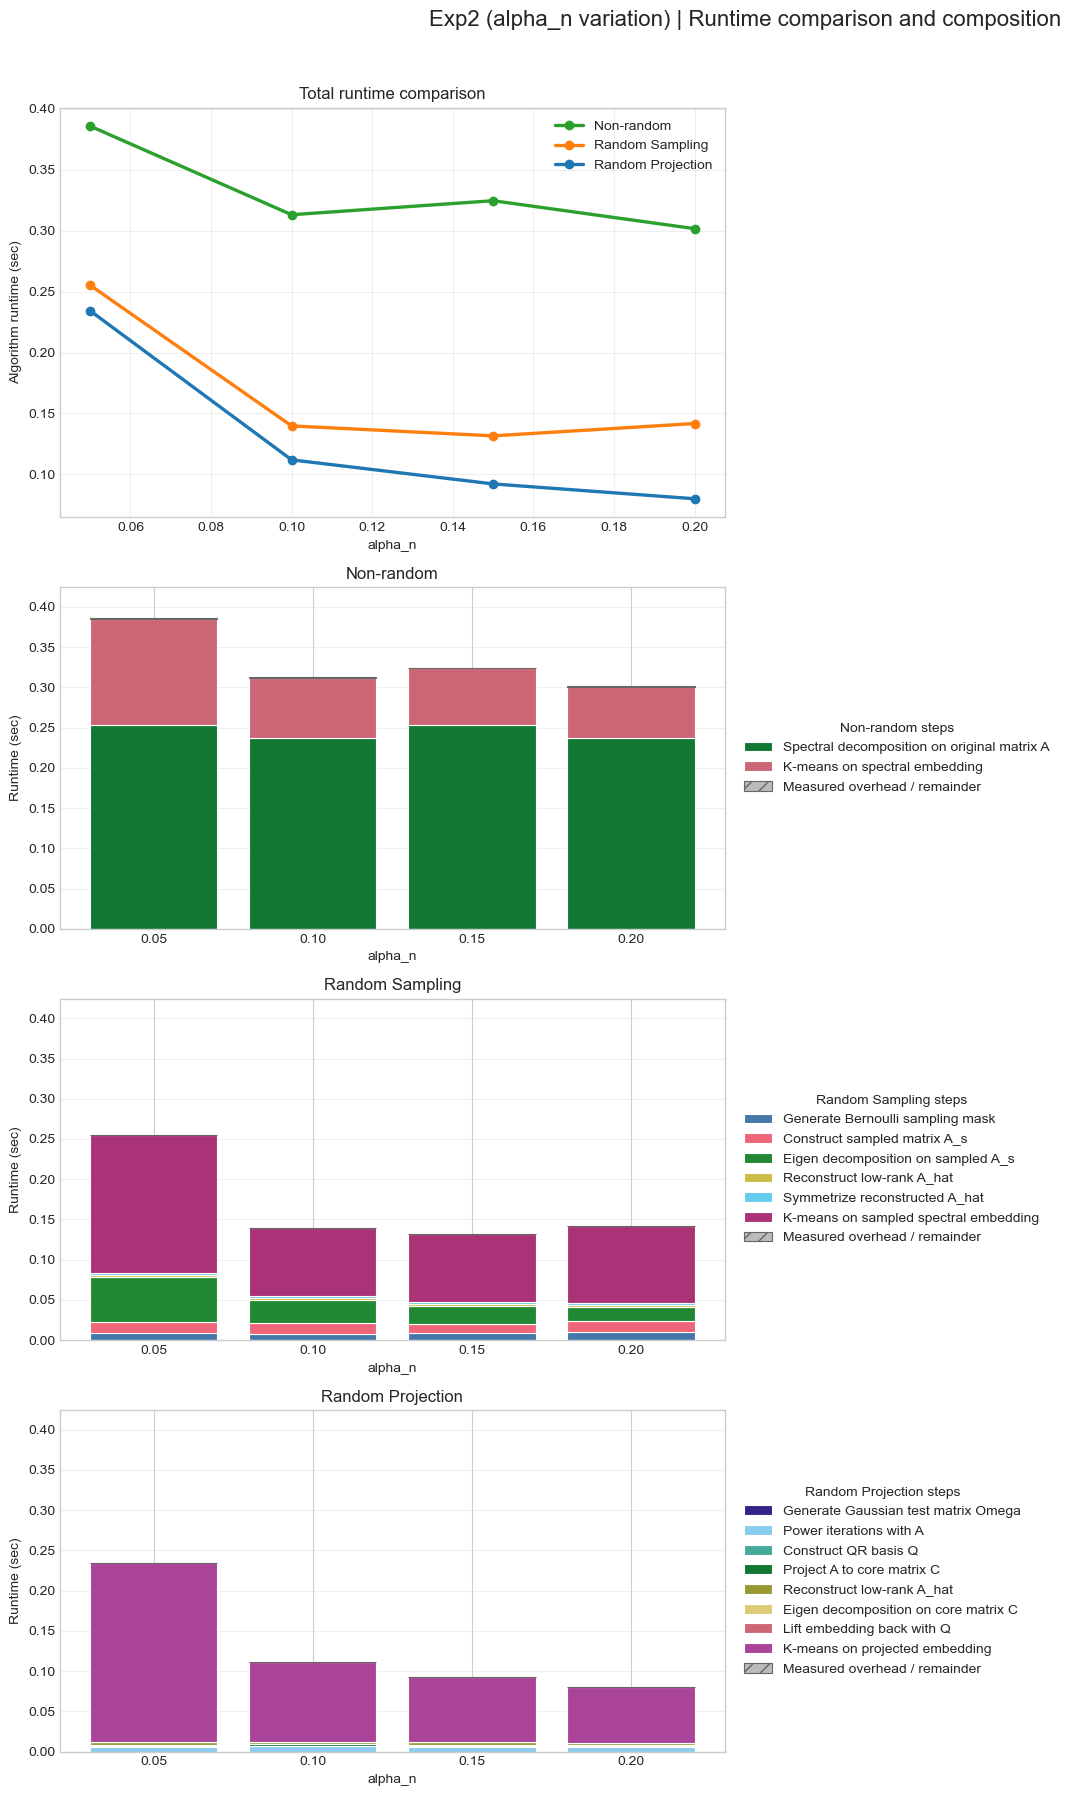

In [4]:
global_limits = compute_global_metric_limits()
breakdown_result, composition_result = render_all_section7_visualizations(
    exp_key="exp2",
    summary_path=outputs.timing_summary_csv,
    global_limits=global_limits,
)


In [5]:
breakdown_result.overall_table.round(6)

,alpha_n,method,time_sec_mean,time_sec_std
0,0.05,Non-random,0.385827,0.070236
1,0.05,Random Projection,0.234250,0.070682
2,0.05,Random Sampling,0.255223,0.063130
3,0.10,Non-random,0.313105,0.047546
4,0.10,Random Projection,0.111890,0.034956
5,0.10,Random Sampling,0.139761,0.031836
6,0.15,Non-random,0.324599,0.056904
7,0.15,Random Projection,0.092140,0.030449
8,0.15,Random Sampling,0.131594,0.031074
9,0.20,Non-random,0.301674,0.038955
